In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("Food_Delivery_Times.csv")
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [3]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [4]:
df.tail()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55
999,103,6.63,Foggy,Low,Night,Scooter,24,3.0,58


In [5]:
df.shape

(1000, 9)

In [6]:
df.columns

Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [8]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


In [9]:
a=[ 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type'
       ]
for i in a:
    print("column:",i)
    print("unique values:")
    print(df[i].unique())
    print("value counts")
    print(df[i].value_counts())

column: Weather
unique values:
['Windy' 'Clear' 'Foggy' 'Rainy' 'Snowy' nan]
value counts
Weather
Clear    470
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64
column: Traffic_Level
unique values:
['Low' 'Medium' 'High' nan]
value counts
Traffic_Level
Medium    390
Low       383
High      197
Name: count, dtype: int64
column: Time_of_Day
unique values:
['Afternoon' 'Evening' 'Night' 'Morning' nan]
value counts
Time_of_Day
Morning      308
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64
column: Vehicle_Type
unique values:
['Scooter' 'Bike' 'Car']
value counts
Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64


In [10]:
#checking null values
print(df.isnull().sum())

Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [11]:
df.fillna({'Weather':df['Weather'].ffill()},inplace=True)

In [12]:
df.fillna({'Traffic_Level':df['Traffic_Level'].ffill()},inplace=True)

In [13]:
df.fillna({'Time_of_Day':df['Time_of_Day'].ffill()},inplace=True)

In [14]:
df.fillna({'Courier_Experience_yrs':df['Courier_Experience_yrs'].mean()},inplace=True)

In [15]:
print(df.isnull().sum())

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


In [16]:
print("minimum of Delivery_Time_min:",np.min(df['Delivery_Time_min']))
print("maximum of Delivery_Time_min:",np.max(df['Delivery_Time_min']))

minimum of Delivery_Time_min: 8
maximum of Delivery_Time_min: 153


In [17]:
print("minimum of Distance_km:",np.min(df['Distance_km']))
print("maximum of Distance_km:",np.max(df['Distance_km']))

minimum of Distance_km: 0.59
maximum of Distance_km: 19.99


In [18]:
print("minimum of Preparation_Time_min:",np.min(df['Preparation_Time_min']))
print("maximum of Preparation_Time_min:",np.max(df['Preparation_Time_min']))

minimum of Preparation_Time_min: 5
maximum of Preparation_Time_min: 29


Time_of_Day
Morning      317
Evening      303
Afternoon    292
Night         88
Name: count, dtype: int64
<class 'pandas.core.series.Series'>
Index(['Morning', 'Evening', 'Afternoon', 'Night'], dtype='object', name='Time_of_Day')
[317 303 292  88]


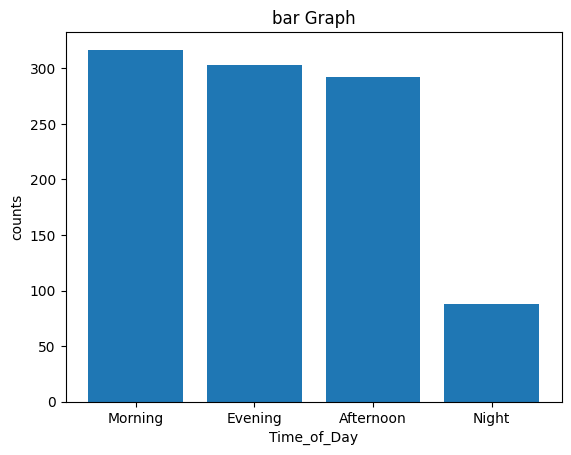

In [19]:
#visualizations
a=df['Time_of_Day'].value_counts()
print(a)
print(type(a))
m=a.index
print(m)
n=a.values
print(n)
plt.bar(m,n)
plt.title("bar Graph")
plt.xlabel("Time_of_Day")
plt.ylabel("counts")
plt.show()

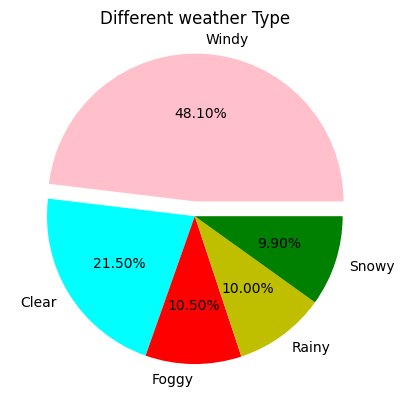

In [20]:
#patient with different worktype---pie chart
x=df['Weather'].value_counts()
work=['Windy','Clear','Foggy','Rainy','Snowy']
m=[0.1,0,0,0,0]
plt.title("Different weather Type")
plt.pie(x,labels=work,colors=['pink','cyan','r','y','g'],explode=m,autopct="%1.2f%%")
plt.show()

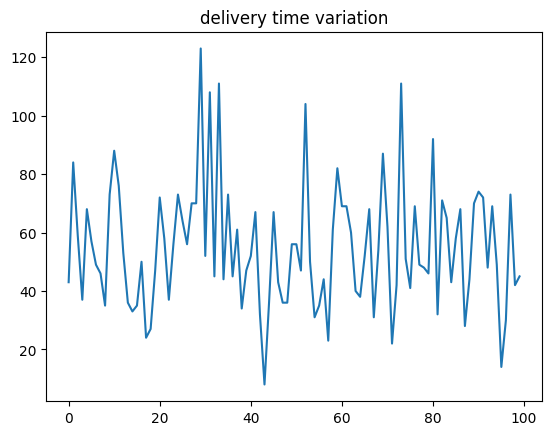

In [21]:
a=df['Delivery_Time_min'].iloc[0:100]
plt.title("delivery time variation")
plt.plot(a)
plt.show()

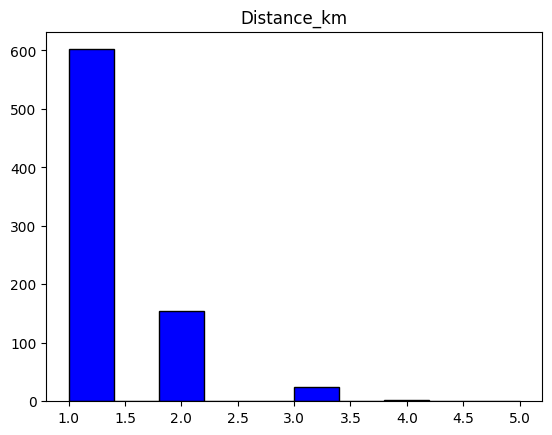

In [22]:
x=df['Distance_km'].value_counts()
plt.hist(x,color='b',edgecolor='k')
plt.title('Distance_km')
plt.show()

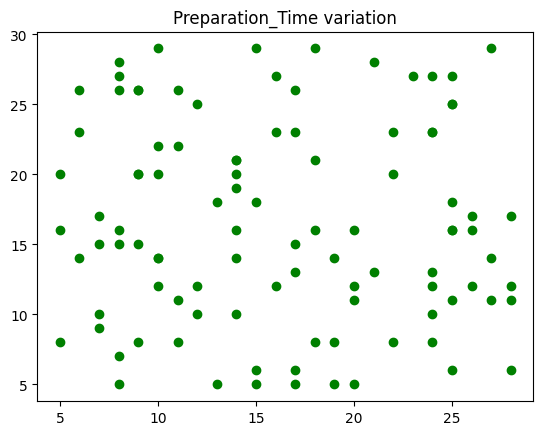

In [23]:
a=df['Preparation_Time_min'].iloc[100:200]
b=df['Preparation_Time_min'].iloc[0:100]
plt.title("Preparation_Time variation")
plt.scatter(a,b,color='g')
plt.show()

In [24]:
df.drop(['Order_ID'],axis=1,inplace=True)
df


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [25]:
df.columns

Index(['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min'],
      dtype='object')

In [26]:
#nominal
#dummy encoding
import pandas as pd
df=pd.get_dummies(df,columns=['Weather'],dtype='int')
df

,Distance_km,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy
0,7.93,Low,Afternoon,Scooter,12,1.0,43,0,0,0,0,1
1,16.42,Medium,Evening,Bike,20,2.0,84,1,0,0,0,0
2,9.52,Low,Night,Scooter,28,1.0,59,0,1,0,0,0
3,7.44,Medium,Afternoon,Scooter,5,1.0,37,0,0,1,0,0
4,19.03,Low,Morning,Bike,16,5.0,68,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,8.50,High,Evening,Car,13,3.0,54,1,0,0,0,0
996,16.28,Low,Morning,Scooter,8,9.0,71,0,0,1,0,0
997,15.62,High,Evening,Scooter,26,2.0,81,0,0,0,1,0
998,14.17,Low,Afternoon,Bike,8,0.0,55,1,0,0,0,0


In [27]:
#nominal
#dummy encoding
import pandas as pd
df=pd.get_dummies(df,columns=['Time_of_Day'],dtype='int')
df

,Distance_km,Traffic_Level,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night
0,7.93,Low,Scooter,12,1.0,43,0,0,0,0,1,1,0,0,0
1,16.42,Medium,Bike,20,2.0,84,1,0,0,0,0,0,1,0,0
2,9.52,Low,Scooter,28,1.0,59,0,1,0,0,0,0,0,0,1
3,7.44,Medium,Scooter,5,1.0,37,0,0,1,0,0,1,0,0,0
4,19.03,Low,Bike,16,5.0,68,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8.50,High,Car,13,3.0,54,1,0,0,0,0,0,1,0,0
996,16.28,Low,Scooter,8,9.0,71,0,0,1,0,0,0,0,1,0
997,15.62,High,Scooter,26,2.0,81,0,0,0,1,0,0,1,0,0
998,14.17,Low,Bike,8,0.0,55,1,0,0,0,0,1,0,0,0


In [28]:
#nominal
#dummy encoding
import pandas as pd
df=pd.get_dummies(df,columns=['Vehicle_Type'],dtype='int')
df

,Distance_km,Traffic_Level,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,Low,12,1.0,43,0,0,0,0,1,1,0,0,0,0,0,1
1,16.42,Medium,20,2.0,84,1,0,0,0,0,0,1,0,0,1,0,0
2,9.52,Low,28,1.0,59,0,1,0,0,0,0,0,0,1,0,0,1
3,7.44,Medium,5,1.0,37,0,0,1,0,0,1,0,0,0,0,0,1
4,19.03,Low,16,5.0,68,1,0,0,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8.50,High,13,3.0,54,1,0,0,0,0,0,1,0,0,0,1,0
996,16.28,Low,8,9.0,71,0,0,1,0,0,0,0,1,0,0,0,1
997,15.62,High,26,2.0,81,0,0,0,1,0,0,1,0,0,0,0,1
998,14.17,Low,8,0.0,55,1,0,0,0,0,1,0,0,0,1,0,0


In [29]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
df['Traffic_Level']=lb.fit_transform(df['Traffic_Level'])
df

,Distance_km,Traffic_Level,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Clear,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,1,12,1.0,43,0,0,0,0,1,1,0,0,0,0,0,1
1,16.42,2,20,2.0,84,1,0,0,0,0,0,1,0,0,1,0,0
2,9.52,1,28,1.0,59,0,1,0,0,0,0,0,0,1,0,0,1
3,7.44,2,5,1.0,37,0,0,1,0,0,1,0,0,0,0,0,1
4,19.03,1,16,5.0,68,1,0,0,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8.50,0,13,3.0,54,1,0,0,0,0,0,1,0,0,0,1,0
996,16.28,1,8,9.0,71,0,0,1,0,0,0,0,1,0,0,0,1
997,15.62,0,26,2.0,81,0,0,0,1,0,0,1,0,0,0,0,1
998,14.17,1,8,0.0,55,1,0,0,0,0,1,0,0,0,1,0,0


In [30]:
df.columns

Index(['Distance_km', 'Traffic_Level', 'Preparation_Time_min',
       'Courier_Experience_yrs', 'Delivery_Time_min', 'Weather_Clear',
       'Weather_Foggy', 'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy',
       'Time_of_Day_Afternoon', 'Time_of_Day_Evening', 'Time_of_Day_Morning',
       'Time_of_Day_Night', 'Vehicle_Type_Bike', 'Vehicle_Type_Car',
       'Vehicle_Type_Scooter'],
      dtype='object')

In [31]:
x=df.drop('Delivery_Time_min',axis=1)
y=df['Delivery_Time_min']

In [32]:
x.columns

Index(['Distance_km', 'Traffic_Level', 'Preparation_Time_min',
       'Courier_Experience_yrs', 'Weather_Clear', 'Weather_Foggy',
       'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy',
       'Time_of_Day_Afternoon', 'Time_of_Day_Evening', 'Time_of_Day_Morning',
       'Time_of_Day_Night', 'Vehicle_Type_Bike', 'Vehicle_Type_Car',
       'Vehicle_Type_Scooter'],
      dtype='object')

In [33]:
print(x.shape)
print(y.shape)

(1000, 16)
(1000,)


In [34]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [35]:
print(x_train.shape)
print(x_test.shape)

(800, 16)
(200, 16)


In [36]:
print(y_train.shape)
print(y_test.shape)

(800,)
(200,)


In [37]:
#Model training
#Linear regression
#1.import algorithm
from sklearn.linear_model import LinearRegression

#2.Object for class
#model
lr=LinearRegression()

In [38]:
#model traning
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
lr_result=lr.predict(x_test)
print(lr_result)

[40.14803368 63.86509799 40.5668136  41.57187217 90.23142751 36.5617046
 65.65766805 31.08590572 32.25840073 72.47002749 71.68179009 65.28048337
 33.33177989 68.10860796 86.12609491 88.45404179 30.1423078  65.85230937
 44.7078614  58.22563405 84.42677686 24.97781073 78.03279448 75.95975241
 58.6199357  31.02598064 80.79792339 23.27128739 47.87009922 64.49307394
 63.91430733 21.66127108 64.61185683 43.14577546 72.0688032  17.95174032
 67.31576994 51.41087232 44.53099727 71.05531018 73.71887654 36.23092726
 76.45566221 66.70309817 40.70894516 19.70000923 88.24268302 87.52354
 83.0431087  31.44095077 60.66282491 62.5561834  43.46329216 76.3089311
 51.90667019 50.82750397 72.29855538 77.9805344  62.09726543 89.10643538
 52.47661526 41.49248802 44.9083855  53.22513894 47.23888597 63.41351875
 66.94928113 86.70401777 70.86672766 54.03937655 76.98107026 30.89098152
 90.62622908 28.96818638 63.10260574 54.74952438 38.96480995 42.53699098
 47.31739292 27.85606791 57.14084819 75.88544395 54.7054

In [40]:
#model evaluation
#checking results based on y_test

print("R^2 score for LR on training set:",lr.score(x_train,y_train))
print("R^2 score for LR on tesit set:",lr.score(x_test,y_test))


#checking for error(checking wrong prrediction)
from sklearn.metrics import mean_absolute_error as mae,mean_squared_error as mse

print("--linear regression--model evaluation--")
print("Mean Absolute Error(MAE):",mae(y_test,lr_result))
print("Mean Squared Error(MSE):",mse(y_test,lr_result))
print("Root Mean Absolute Error(RMSE):",np.sqrt(mse(y_test,lr_result)))


R^2 score for LR on training set: 0.7335314563364437
R^2 score for LR on tesit set: 0.7756542528473221
--linear regression--model evaluation--
Mean Absolute Error(MAE): 6.976293721049469
Mean Squared Error(MSE): 100.55781560035965
Root Mean Absolute Error(RMSE): 10.027851993341327


In [41]:
#Model training
#DecisionTreeRegressor
#1.import algorithm
from sklearn.tree import DecisionTreeRegressor

#2.Object for class
#model
dt=DecisionTreeRegressor()

In [42]:
#model traning
dt.fit(x_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [43]:
dt_result=dt.predict(x_test)
print(dt_result)

[ 42.  73.  28.  49.  72.  26.  74.  25.  27.  96.  72.  67.  21.  80.
  98.  83.  28.  57.  52.  54.  72.  32.  92.  48.  65.  70.  92.  22.
  42.  49.  52.  18.  52.  41.  79.   8.  60.  37.  44.  92.  63.  34.
  75.  57.  39.  14. 141.  69.  67.  28.  74.  55.  49.  68.  60.  54.
  74.  79.  58.  92.  65.  31.  59.  60.  58.  65.  71. 103.  71.  60.
  54.  34.  85.  25.  71.  63.  28.  49.  42.  27.  54.  77. 113.  27.
  25.  70.  63.  91.  37.  58.  45.  60.  49.  29.  58.  71.  46.  53.
  47.  70.  35.  48.  33.  27.  47.  16.  52.  17. 141.  34.  85.  53.
  76.  32.  74.  34.  80.  91.  27.  60.  60.  60.  48.  56.  58.  71.
  32.  49.  58.  46.  45.  48.  82.  48.  74.  39.  82.  71.  71.  71.
  41.  72.  53.  71.  61.  53.  83.  72. 123.  40.  42.  56.  82. 141.
  52.  35.  51.  45.  89.  71.  83.  84.  62.  50.  44.  68.  87.  68.
  49.  71.  49.  65.  38.  52.  23.  64.  62.  27.  71.  97.  47.  41.
  60.  50.  77.  43.  31.  71.  56.  27. 116.  16.  51.  42.  43.  77.
  34. 

In [44]:
#model evaluation
#checking results based on y_test

print("R^2 score for DT on training set:",dt.score(x_train,y_train))
print("R^2 score for DT on tesit set:",dt.score(x_test,y_test))


#checking for error(checking wrong prrediction)
from sklearn.metrics import mean_absolute_error as mae,mean_squared_error as mse

print("--Decision Tree--model evaluation--")
print("Mean Absolute Error(MAE):",mae(y_test,dt_result))
print("Mean Squared Error(MSE):",mse(y_test,dt_result))
print("Root Mean Absolute Error(RMSE):",np.sqrt(mse(y_test,dt_result)))


R^2 score for DT on training set: 1.0
R^2 score for DT on tesit set: 0.4181965509773258
--Decision Tree--model evaluation--
Mean Absolute Error(MAE): 11.12
Mean Squared Error(MSE): 260.78
Root Mean Absolute Error(RMSE): 16.14868415692127


In [45]:
#Model training
#DecisionTreeRegressor
#1.import algorithm
from sklearn.ensemble import RandomForestRegressor

#2.Object for class
#model
rf=RandomForestRegressor()
#model traning
rf.fit(x_train,y_train)

rf_result=rf.predict(x_test)
print(rf_result)

[34.54 66.79 42.21 42.03 86.79 36.95 64.05 33.87 33.17 74.85 75.16 65.9
 37.38 76.46 87.93 84.64 30.25 65.03 49.62 56.45 83.79 29.9  68.14 77.82
 62.11 35.28 78.84 24.97 50.43 58.93 66.72 21.28 55.6  41.38 73.32 16.95
 66.1  53.09 48.17 81.15 73.18 33.38 74.47 69.16 40.96 19.08 94.76 81.13
 84.27 30.19 69.89 58.58 40.94 78.54 53.64 52.42 75.01 76.23 61.4  86.21
 53.02 35.45 53.83 49.17 49.63 57.19 70.18 92.29 63.86 55.47 77.35 35.77
 83.3  26.54 64.5  63.16 41.35 42.03 48.82 30.94 60.13 73.73 63.58 27.9
 31.06 69.63 62.39 79.9  47.   65.55 47.98 67.22 50.15 41.2  58.76 70.39
 52.97 54.25 38.3  40.31 30.25 53.42 28.88 26.47 49.44 22.5  45.75 17.42
 97.25 37.66 69.03 54.45 66.87 45.54 90.55 36.84 59.36 73.8  29.78 59.22
 64.02 80.48 53.23 60.88 50.23 69.94 34.58 63.   50.84 41.27 46.5  51.39
 83.13 49.66 66.1  47.6  81.1  68.08 71.59 49.83 45.02 40.58 64.92 65.13
 51.57 57.33 93.41 69.68 91.35 36.12 37.55 66.29 62.31 94.85 42.55 25.81
 46.29 36.71 70.35 69.   89.05 86.31 65.87 55.39 40.0

In [46]:
#model evaluation
#checking results based on y_test

print("R^2 score for RF on training set:",rf.score(x_train,y_train))
print("R^2 score for RF on tesit set:",rf.score(x_test,y_test))


#checking for error(checking wrong prrediction)
from sklearn.metrics import mean_absolute_error as mae,mean_squared_error as mse

print("--Random Forest--model evaluation--")
print("Mean Absolute Error(MAE):",mae(y_test,rf_result))
print("Mean Squared Error(MSE):",mse(y_test,rf_result))
print("Root Mean Absolute Error(RMSE):",np.sqrt(mse(y_test,rf_result)))


R^2 score for RF on training set: 0.9587319340038541
R^2 score for RF on tesit set: 0.7745355486469774
--Random Forest--model evaluation--
Mean Absolute Error(MAE): 7.1254
Mean Squared Error(MSE): 101.05924899999998
Root Mean Absolute Error(RMSE): 10.052822936867036


In [47]:
#Model training
#DecisionTreeRegressor
#1.import algorithm
from sklearn.svm import SVR

#2.Object for class
#model
svm=SVR()
#model traning
svm.fit(x_train,y_train)


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [48]:
svm_result=svm.predict(x_test)
print(svm_result)

[39.00704995 64.34017156 33.90305806 43.41166232 80.41971731 37.12487835
 63.39702968 32.93513524 28.84008529 65.84260567 69.22082007 65.27976074
 32.3397586  68.40133214 81.82154447 81.60336237 31.02869426 66.73334358
 43.06656162 60.12637612 79.15059119 27.99274357 68.90905007 72.20252317
 52.35840858 30.89523685 73.48714357 26.81079543 47.83188694 60.92916437
 57.78089691 26.80621128 58.57026958 41.71608482 69.52423648 26.54997451
 66.78447705 53.82146726 47.55954046 67.58689309 69.96435752 39.85146046
 69.13898513 66.6452611  34.25077364 26.2812124  80.54648005 80.10646328
 77.63804918 34.15249075 54.16786771 61.98643914 42.6136207  71.5394295
 51.03090447 54.32024437 69.39262297 70.79726913 59.13748248 80.9907111
 49.47331258 40.31508254 39.38411555 50.90056555 48.11474403 59.74047114
 68.30003895 81.07976627 59.18680819 48.4572992  70.2270507  34.16209898
 79.59039531 30.92570415 64.80740305 54.33935067 40.55118183 40.8560021
 44.39137989 29.49656508 57.1998759  70.57953006 58.05

In [49]:
#model evaluation
#checking results based on y_test

print("R^2 score for SVM on training set:",svm.score(x_train,y_train))
print("R^2 score for SVM on tesit set:",svm.score(x_test,y_test))


#checking for error(checking wrong prrediction)
from sklearn.metrics import mean_absolute_error as mae,mean_squared_error as mse

print("--SVM--model evaluation--")
print("Mean Absolute Error(MAE):",mae(y_test,svm_result))
print("Mean Squared Error(MSE):",mse(y_test,svm_result))
print("Root Mean Absolute Error(RMSE):",np.sqrt(mse(y_test,svm_result)))


R^2 score for SVM on training set: 0.6857933662541884
R^2 score for SVM on tesit set: 0.7255018980329144
--SVM--model evaluation--
Mean Absolute Error(MAE): 7.77632145586182
Mean Squared Error(MSE): 123.03745388794829
Root Mean Absolute Error(RMSE): 11.092224929559817


In [50]:
import joblib

#save model
joblib.dump(rf,'rf_model_delivery_time.pkl')

#save coumn structure(imp)
joblib.dump(x.columns.tolist(),'scaler_rf_model_delivery_time.pkl')

#save label encoder(for traffic_level)
joblib.dump(rf,"traffic_encoder.pkl")

print("model saved successfully")

model saved successfully


In [ ]:
#Test
model=joblib.load('rf_model_delivery_time.pkl')
scaler=joblib.load('scaler_rf_model_delivery_time.pkl')

Distance_km=float(input("Enter the distance value:"))
Traffic_Level=input("Enter the Traffic Level(Low-1/Medium-2/High-0):")
Preparation_Time_min=int(input("Enter the preparation time in minutes:"))
Courier_Experience_yrs=float(input("Enter the courier experience in years:"))
Weather=input("Enter the weather type(Windy/Clear/Foggy/Rainy/Snowy):")
Time_of_Day=input("Enter the time of day(Afternoon/Evening/Morning/Night):")
Vehicle_Type=input("Enter the vehicle type(Bike/Car/Scooter):")

if Traffic_Level=='High':
    Traffic_Level=0
elif Traffic_Level=='Low':
    Traffic_Level=1
else:
    Traffic_Level=2  

Weather_Clear, Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy=0,0,0,0,0
if Weather=='Clear':
   Weather_Clear=1
elif Weather=='Foggy':
   Weather_Foggy=1
elif Weather=='Rainy':
   Weather_Rainy=1
elif Weather=='Snowy':
   Weather_Snowy=1    
else:
   Weather_Windy=1 

Time_of_Day_Afternoon,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night=0,0,0,0
if Time_of_Day=='Afternoon':
   Time_of_Day_Afternoon=1
elif Time_of_Day=='Evening':
   Time_of_Day_Evening=1
elif Time_of_Day=='Morning':
   Time_of_Day_Morning=1  
else:
   Time_of_Day_Night=1 

Vehicle_Type_Bike,Vehicle_Type_Car,Vehicle_Type_Scooter=0,0,0
if Vehicle_Type=='Bike':
    Vehicle_Type_Bike=1
elif Vehicle_Type=='Car':
    Vehicle_Type_Car=1    
else:
     Vehicle_Type_Scooter=1  

data=pd.DataFrame([[Distance_km,Traffic_Level,Preparation_Time_min,
       Courier_Experience_yrs, Weather_Clear,Weather_Foggy,Weather_Rainy,
       Weather_Snowy,Weather_Windy,Time_of_Day_Afternoon, Time_of_Day_Evening, 
       Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Bike,Vehicle_Type_Car,
       Vehicle_Type_Scooter]],columns=['Distance_km', 'Traffic_Level', 'Preparation_Time_min',
       'Courier_Experience_yrs', 'Weather_Clear', 'Weather_Foggy',
       'Weather_Rainy', 'Weather_Snowy', 'Weather_Windy',
       'Time_of_Day_Afternoon', 'Time_of_Day_Evening', 'Time_of_Day_Morning',
       'Time_of_Day_Night', 'Vehicle_Type_Bike', 'Vehicle_Type_Car',
       'Vehicle_Type_Scooter'])

result=model.predict(data)
print(result)
 

Enter the distance value: 7.93
Enter the Traffic Level(Low-1/Medium-2/High-0): Low-1
Enter the preparation time in minutes: 12
Enter the courier experience in years: 1.0
Enter the weather type(Windy/Clear/Foggy/Rainy/Snowy): Windy
Enter the time of day(Afternoon/Evening/Morning/Night): Afternoon
Enter the vehicle type(Bike/Car/Scooter): Scooter


[46.39]
